In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

In [2]:
def sigmoid(z):
    """
    Computes the Sigmoid of z
    Parameters:
        z (array like): A Scalar or NumPy array of any size
    Returns:
        g (Array like): Sigmoid(z)
    """

    z = np.clip(z, -500, 500) #Protects against overflow
    g = 1.0 / (1.0 + np.exp(-z))

    return g

In [3]:
def plot_data(X, y, ax, pos_label = 'y = 1', neg_label = 'y = 0', s = 80, loc = 'best'):
    """Plots Logistic data with 2 axis"""
    #Finding indices of -ve and +ve examples
    pos = y == 1
    neg = y == 0

    #work with 1D or 1D y vectors
    pos = pos.reshape(-1, )
    neg = neg.reshape(-1, )

    #plotting examples
    ax.scatter(
        X[pos, 0],
        X[pos, 1],
        marker = 'x',
        s = s,
        c = 'r',
        label = pos_label
    )
    ax.scatter(
        X[neg, 0],
        X[neg, 1],
        marker = 'o',
        label = neg_label,
        facecolor = 'none',
        edgecolor = 'b',
        lw = 3
    )
    ax.legend(loc = loc)

    ax.figure.canvas.toolbar_visible = False
    ax.figure.canvas.header_visible = False
    ax.figure.canvas.footer_visible = False

In [4]:
def draw_vthresh(ax, x):
    """Draws a threshold at 0.5"""
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    ax.fill_between(
        [xlim[0], x],
        [ylim[1], ylim[1]],
        alpha = 0.2,
        color = 'b'
    )
    ax.fill_between(
        [x, xlim[1]],
        [ylim[1], ylim[1]],
        alpha = 0.2,
        color = 'r'
    )
    ax.annotate(
        "z >= 0",
        xy = [x, 0.5],
        xycoords = 'data',
        xytext = [30, 5],
        textcoords = 'offset points'
    )
    d = FancyArrowPatch(
        posA = (x, 0.5),
        posB = (x + 3, 0.5),
        color = 'r',
        arrowstyle = 'simple, head_width = 5, head_length = 10, tail_width = 0.0',
    )
    ax.add_artist(d)

    ax.annotate(
        "z < 0",
        xy = [x, 0.5],
        xycoords = 'data',
        xytext = [-50, 5],
        textcoords = 'offset points',
        ha = 'left'
    )
    f = FancyArrowPatch(
        posA = (x, 0.5),
        posB = (x - 3, 0.5),
        color = 'b',
        arrowstyle = 'simple, head_width = 5, head_length = 10, tail_width = 0.0',
    )
    ax.add_artist(f)

# Dataset
- Input variable 'X' is a NumPy array which has 6 training examples,each with 2 features.
- Output variable 'y' is also a NumPy array with 6 examples, and 'y' is either 0 or 1

In [26]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1)

# Plotting Data
- Red crosses ---> data points with y = 1
- blie circles ---> data points with y = 0

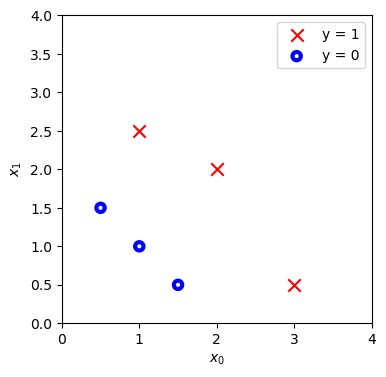

In [28]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
plot_data(X, y, ax)
ax.axis([0, 4, 0, 4])
ax.set_ylabel("$x_1$")
ax.set_xlabel("$x_0$")
plt.show()

# Logistic Regression Model
- Training the logistic regression model on this data of the form
  $$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b) \tag{1}$$
  where,  $g(z) = \frac{1}{1+e^{-z}}\tag{2}$, which is the sigmoid function.

- Let's say the parameters are b = -0.7, w0 = 1, w1 = . That is,


      f(x) = g(x_0+x_1-3)

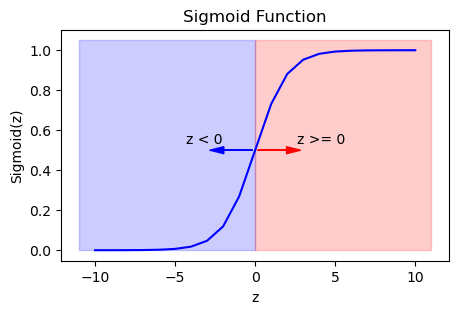

In [29]:
#Plotting Sigmoid(z) over a range of values from -10 to 10
z = np.arange(-10, 11)
fig, ax = plt.subplots(1, 1, figsize = (5, 3))

#Plotting z vs. Sigmoid(z)
ax.plot(z, sigmoid(z), c = 'b')
ax.set_title("Sigmoid Function")
ax.set_ylabel("Sigmoid(z)")
ax.set_xlabel("z")
draw_vthresh(ax, 0)
plt.show()

# Plotting Decision Boundary

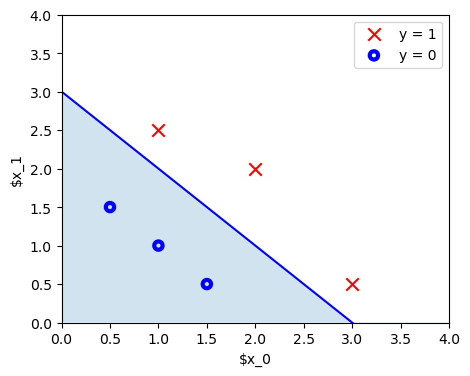

In [32]:
x0 = np.arange(0, 6)
x1 = 3 - x0
fig, ax = plt.subplots(1, 1, figsize = (5, 4))

#plotting decision boundary
ax.plot(x0, x1, c = 'b')
ax.axis([0, 4, 0, 4])

#fitting the region below the line
ax.fill_between(x0, x1, alpha = 0.2)

#plotting original data
plot_data(X, y, ax)
ax.set_ylabel(r"$x_1")
ax.set_xlabel(r"$x_0")
plt.show()